# **Predicting Nitrate Danger in Alberta Wells: Neural Networks vs. Logistic Regression**

# Data Check & Processing

In [ ]:
import pandas as pd
import numpy as np

file_path = '/content/sample_data/health-dwwq-routine-chemistry-analysis-data_2019-2020_20260303.xlsx'
df = pd.read_excel(file_path)
df.head(5)

,SampleID,Date,Source,WellDepth,Alkalinity,Bicarbonate,Calcium,Carbonate,Chloride,Conductivity,...,Potassium,Iron,Sodium,Sulfate,TDS,Latitude,Longitude,STRM,Well ID,WPAC
0,T167480,2019-01-02,Well,20,132.0,161.0,39.2,0.0,6.4,304.0,...,10.0,0.10,7.6,4.9,157.0,54.129374,-111.740906,S28T59R12M4,U,North Saskatchewan Watershed Alliance
1,T167481,2019-01-02,Well,43,527.0,642.0,144.0,0.0,2.0,1189.0,...,5.6,0.01,52.5,185.0,761.0,54.143974,-111.590938,S33T59R11M4,U,North Saskatchewan Watershed Alliance
2,T192754,2019-01-02,Well,39,351.0,412.0,19.0,7.8,25.6,757.0,...,2.2,0.06,153.0,26.2,443.0,52.399344,-114.829556,S32T39R6M5,U,Red Deer River Watershed Alliance
3,T192862,2019-01-02,Well,165,333.0,406.0,81.6,0.0,3.5,615.0,...,2.2,0.40,11.4,14.4,346.0,52.268132,-114.894270,S14T38R7M5,U,North Saskatchewan Watershed Alliance
4,T197357,2019-01-02,Well,205,536.0,594.0,2.1,29.7,1.7,1062.0,...,1.0,-0.01,261.0,47.9,639.0,51.380096,-114.060483,S10T28R1M5,9866021,Bow River Basin Council


In [ ]:
# check missing values
print("Missing values count：")
print(df.isna().sum())

# check data types
print("\nPreview of Data Types：")
print(df.dtypes)

Missing values count：
SampleID        0
Date            0
Source          0
WellDepth       0
Alkalinity      0
Bicarbonate     0
Calcium         0
Carbonate       0
Chloride        0
Conductivity    0
Fluoride        0
Hardness        0
Hydroxide       0
Magnesium       0
Nitrate         0
Nitrite         0
pH              0
Potassium       0
Iron            0
Sodium          0
Sulfate         0
TDS             0
Latitude        0
Longitude       0
STRM            0
Well ID         0
WPAC            0
dtype: int64

Preview of Data Types：
SampleID                object
Date            datetime64[ns]
Source                  object
WellDepth                int64
Alkalinity             float64
Bicarbonate            float64
Calcium                float64
Carbonate              float64
Chloride               float64
Conductivity           float64
Fluoride               float64
Hardness               float64
Hydroxide                int64
Magnesium              float64
Nitrate              

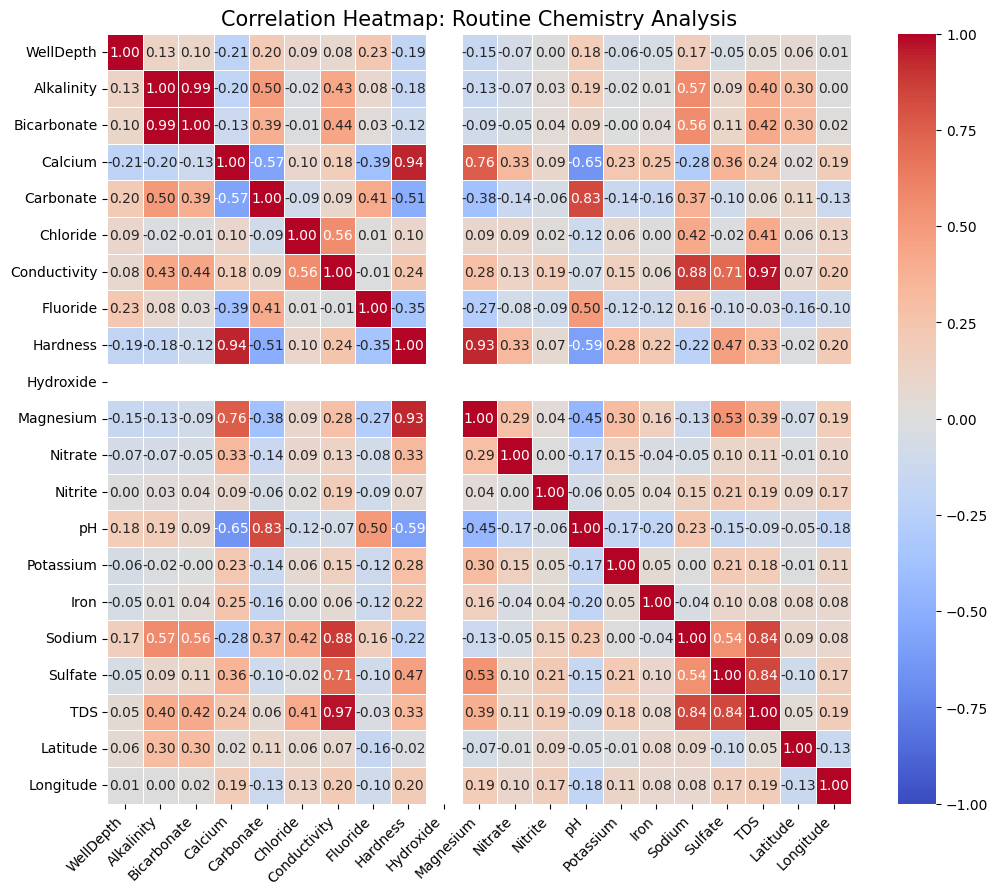

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data Cleaning for Correlation
# Correlation only works on numerical data.
# We filter only numeric columns and drop rows with NaN to get accurate results.
numeric_df = df.select_dtypes(include=[np.number])
clean_numeric_df = numeric_df.dropna()

# Calculate the Pearson Correlation Matrix
# This creates a table showing how variables relate to each other (-1 to 1)
corr_matrix = clean_numeric_df.corr()

# Generate the Heatmap
plt.figure(figsize=(12, 10)) # Set the size of the visualization

# Create the heatmap using Seaborn
sns.heatmap(
    corr_matrix,
    annot=True,          # Display the correlation values in each cell
    cmap='coolwarm',     # Use a Red-Blue color scheme (Red = Positive, Blue = Negative)
    fmt=".2f",           # Format values to 2 decimal places
    vmin=-1, vmax=1,      # Set the color scale limits
    center=0,            # Center the color scale at zero
    linewidths=.5        # Add a small gap between cells for readability
)

# Add Chart Labels and Display
plt.title('Correlation Heatmap: Routine Chemistry Analysis', fontsize=15)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better fit
plt.show()

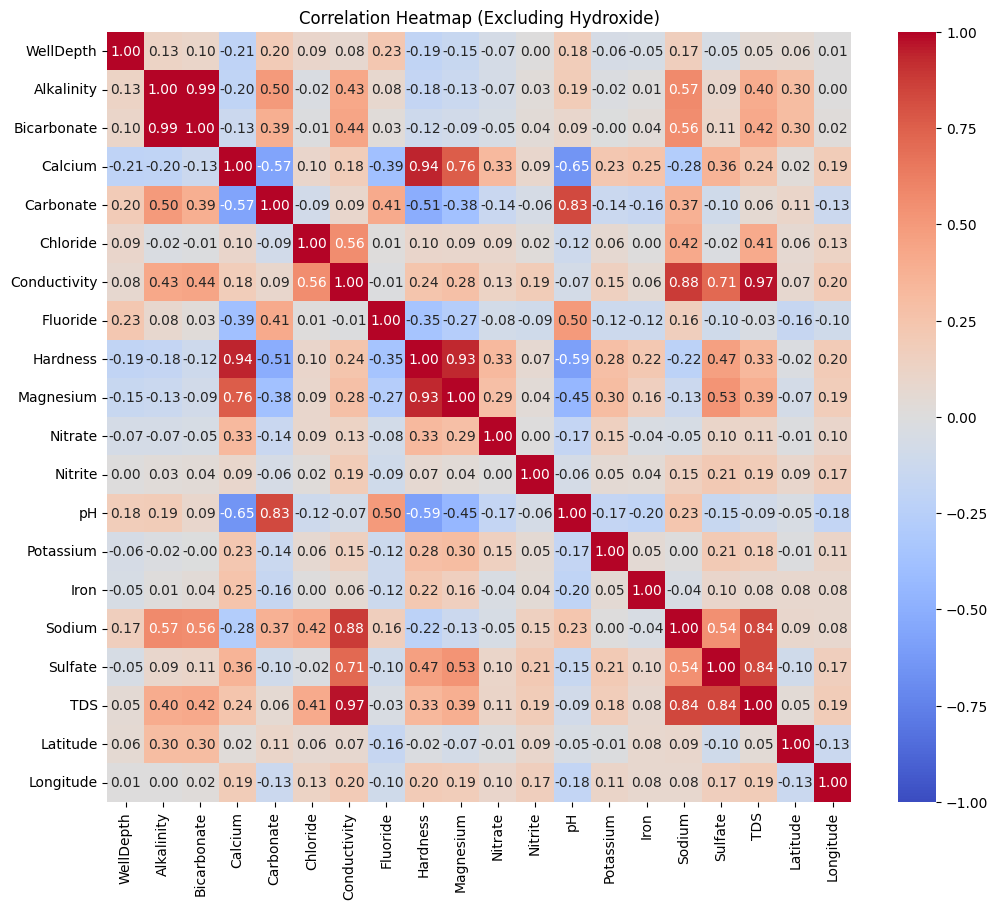

In [ ]:
# Drop the specific column 'Hydroxide'
# axis=1 tells Pandas to look for a column name, not a row index
df_cleaned = df.drop(columns=['Hydroxide'], errors='ignore')

# Calculate the correlation on the remaining numerical data
# We still use numeric_only=True to skip text columns like ID (if it's a string)
corr_matrix = df_cleaned.corr(numeric_only=True)

# Generate the Heatmap (same as before, but with the new matrix)
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1, vmax=1,
    center=0
)

plt.title('Correlation Heatmap (Excluding Hydroxide)')
plt.show()

In [ ]:
# Save the cleaned DataFrame to the Google Colab environment
# 'index=False' prevents Pandas from adding a new column of row numbers
df_cleaned.to_csv('cleaned_health_data.csv', index=False)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset saved successfully as 'cleaned_health_data.csv'


# **EDA_Preliminary_Analyses**

In [ ]:
df = df_cleaned
df.columns

Index(['SampleID', 'Date', 'Source', 'WellDepth', 'Alkalinity', 'Bicarbonate',
       'Calcium', 'Carbonate', 'Chloride', 'Conductivity', 'Fluoride',
       'Hardness', 'Magnesium', 'Nitrate', 'Nitrite', 'pH', 'Potassium',
       'Iron', 'Sodium', 'Sulfate', 'TDS', 'Latitude', 'Longitude', 'STRM',
       'Well ID', 'WPAC'],
      dtype='object')

In [ ]:
df = df[df['Nitrate'] >= 0]  #handle outliers
df['unsafe'] = (df['Nitrate'] > 10).astype(int) #create target(binary classification)
df['unsafe'].value_counts() #check the distribution

/tmp/ipykernel_4963/3145193961.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['unsafe'] = (df['Nitrate'] > 10).astype(int) #create target(binary classification)


,count
unsafe,
0,1432
1,118


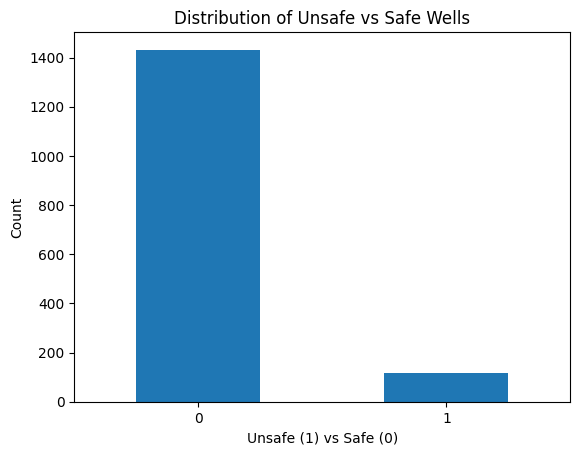

In [ ]:
import matplotlib.pyplot as plt

# Plot the distribution of unsafe vs safe wells
df['unsafe'].value_counts().plot(kind='bar')
plt.title('Distribution of Unsafe vs Safe Wells')
plt.xlabel('Unsafe (1) vs Safe (0)')
plt.ylabel('Count')

plt.xticks(rotation=0)

plt.show()

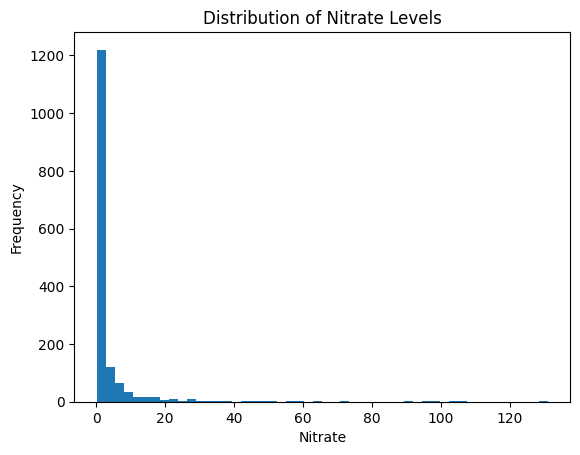

In [ ]:
# Plot and save the distribution of nitrate levels
plt.hist(df['Nitrate'], bins=50)
plt.title('Distribution of Nitrate Levels')
plt.xlabel('Nitrate')
plt.ylabel('Frequency')

plt.savefig('nitrate_distribution.png', dpi=300, bbox_inches='tight')  # save figure
plt.show()

**Interpretation**

The distribution of nitrate levels is highly right-skewed, with most observations concentrated at low values and a small number of samples exhibiting extremely high concentrations. This indicates the presence of outliers and non-normality in the data, which may affect model performance and should be considered during preprocessing.

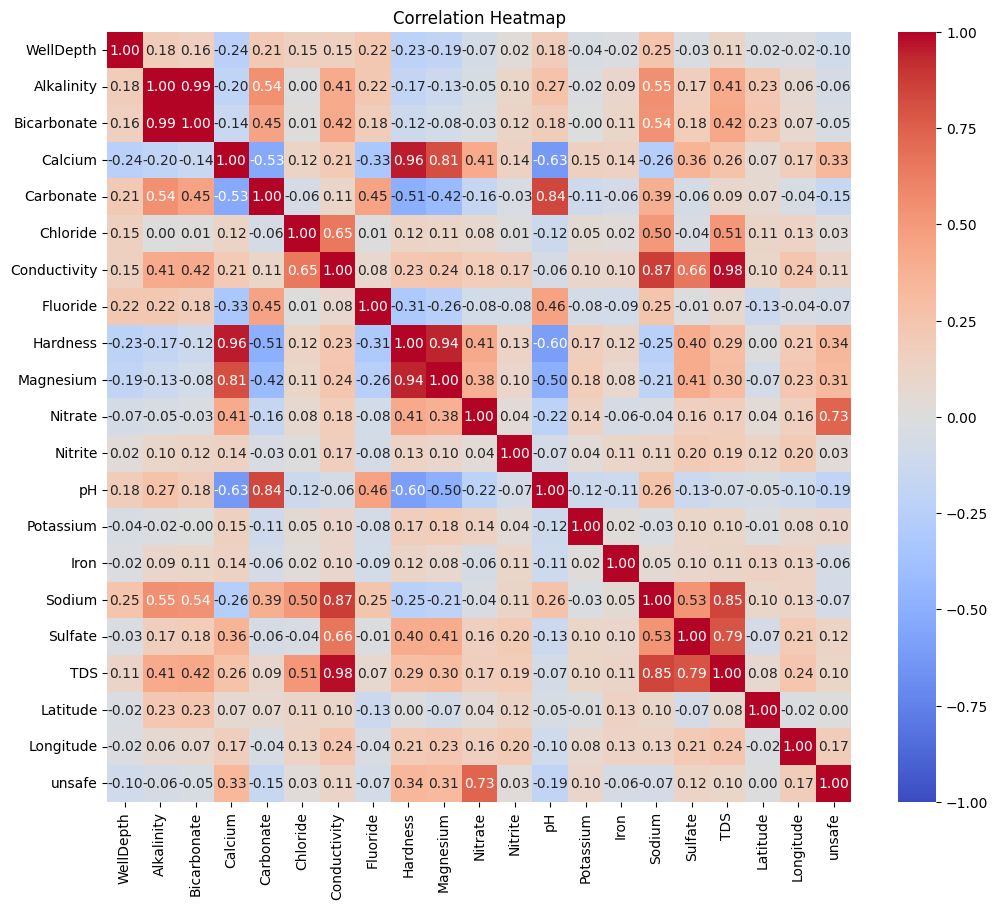

In [ ]:
# Plot and save correlation heatmap
import seaborn as sns

# Calculate the correlation on the remaining numerical data
# We still use numeric_only=True to skip text columns like ID (if it's a string)
corr_matrix = df.corr(numeric_only=True)

# Generate the Heatmap (same as before, but with the new matrix)
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1, vmax=1,
    center=0
)

plt.title('Correlation Heatmap')

plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')  # save figure
plt.show()

The correlation heatmap shows the relationships between numerical variables in the dataset. Some variables, such as conductivity and TDS, and hardness with calcium and magnesium, have strong correlations, suggesting that they contain similar information. Most variables show weak to moderate relationships with the target (unsafe), except for nitrate, which is strongly related as expected. Based on these patterns, feature selection will be applied to reduce redundancy and prepare the data for modeling.

In [ ]:
import requests
import pandas as pd

#check correction with roads
url = "https://geospatial.alberta.ca/titan/rest/services/utility/access/MapServer/28/query?where=1%3D1&outFields=*&returnGeometry=true&f=pjson&resultRecordCount=1000"
data = requests.get(url).json()
features = data['features']

df_road = pd.json_normalize(features)
df_road.head()

,attributes.OBJECTID,attributes.FEATURE_CODE,attributes.FEATURE_TYPE,attributes.SOURCE,attributes.CAPTURE_DATE,geometry.x,geometry.y
0,1,AR55350000,PORT-OF-ENTRY-EVENT,IRSADD,931219200000,722264.883771,5.429577e+06
1,2,CZ16280000,MISC-CNTRL-DEV-EVENT,SUPADD,1183766400000,464385.636853,5.975524e+06
2,3,DD05600000,BRIDGE,SUPADD,1108425600000,543251.635657,5.703029e+06
3,4,DD05600000,BRIDGE,SUPADD,1108425600000,524770.688867,5.693203e+06
4,5,DD05600000,BRIDGE,SUPADD,1108425600000,529029.820406,5.692359e+06


In [ ]:
# Keep only road point coordinates and rename columns
df_road = df_road[['geometry.x', 'geometry.y']].copy()
df_road.columns = ['x_road', 'y_road']

df_road.head()

,x_road,y_road
0,722264.883771,5.429577e+06
1,464385.636853,5.975524e+06
2,543251.635657,5.703029e+06
3,524770.688867,5.693203e+06
4,529029.820406,5.692359e+06


In [ ]:
# Convert well Latitude/Longitude to the same projected coordinate system as road points
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3400", always_xy=True)

df['x_well'], df['y_well'] = transformer.transform(
    df['Longitude'].values,
    df['Latitude'].values
)

df[['Latitude', 'Longitude', 'x_well', 'y_well']].head()

/tmp/ipykernel_4963/1078091621.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['x_well'], df['y_well'] = transformer.transform(
/tmp/ipykernel_4963/1078091621.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['x_well'], df['y_well'] = transformer.transform(


,Latitude,Longitude,x_well,y_well
0,54.129374,-111.740906,712848.019347,6.000424e+06
6,51.292315,-113.954908,572841.895894,5.680577e+06
7,51.292824,-114.060433,565486.332983,5.680534e+06
23,54.755606,-113.321413,607980.041154,6.066460e+06
32,51.175903,-114.315719,547814.557137,5.667340e+06


In [ ]:
# Prepare road point coordinates as numpy array
road_coords = df_road[['x_road', 'y_road']].dropna().values
road_coords[:5]

array([[ 722264.88377101, 5429576.88482361],
       [ 464385.63685324, 5975524.0467194 ],
       [ 543251.63565665, 5703028.96426   ],
       [ 524770.68886682, 5693203.01511061],
       [ 529029.82040566, 5692359.18210399]])

In [ ]:
# Compute approximate nearest distance from each well to a road point
import numpy as np

def compute_min_distance(well_point, road_points):
    distances = np.sqrt(((road_points - well_point) ** 2).sum(axis=1))
    return distances.min()

well_coords = df[['x_well', 'y_well']].dropna().values

df = df.dropna(subset=['x_well', 'y_well']).copy()
df['distance_to_road'] = [
    compute_min_distance(w, road_coords)
    for w in well_coords
]

df[['x_well', 'y_well', 'distance_to_road']].head()

,x_well,y_well,distance_to_road
0,712848.019347,6.000424e+06,15042.159428
6,572841.895894,5.680577e+06,3388.197083
7,565486.332983,5.680534e+06,4238.043803
23,607980.041154,6.066460e+06,4286.651303
32,547814.557137,5.667340e+06,10074.821021


In [ ]:
# Quick check of the new spatial feature
df['distance_to_road'].describe()

,distance_to_road
count,1550.000000
mean,18371.447274
std,20683.572397
min,341.758801
25%,6581.592692
50%,11985.126950
75%,22475.327885
max,143848.796857


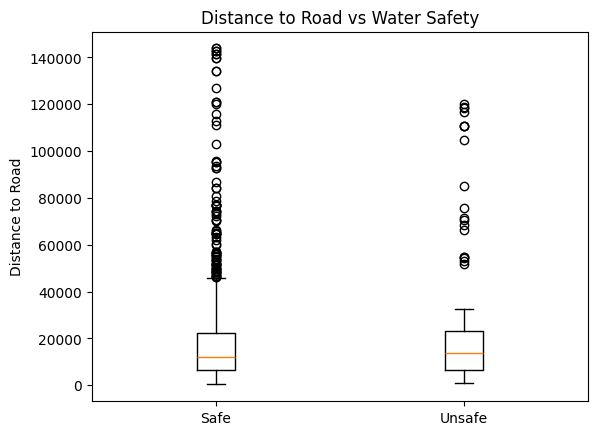

In [ ]:
# distance vs unsafe
import matplotlib.pyplot as plt

plt.figure()

plt.boxplot([
    df[df['unsafe']==0]['distance_to_road'],
    df[df['unsafe']==1]['distance_to_road']
])

plt.xticks([1,2], ['Safe', 'Unsafe'])
plt.ylabel('Distance to Road')
plt.title('Distance to Road vs Water Safety')

plt.savefig('distance_vs_unsafe.png', dpi=300, bbox_inches='tight')
plt.show()

The boxplot shows substantial overlap in distance distributions between safe and unsafe wells. Although unsafe wells exhibit a slightly higher median distance, the difference is not pronounced, indicating that proximity to roads alone does not clearly distinguish unsafe wells.

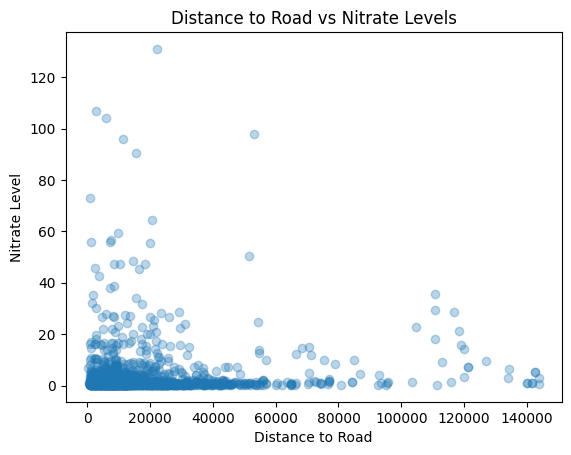

In [ ]:
#distance vs nitrate
plt.figure()

plt.scatter(df['distance_to_road'], df['Nitrate'], alpha=0.3)

plt.xlabel('Distance to Road')
plt.ylabel('Nitrate Level')
plt.title('Distance to Road vs Nitrate Levels')

plt.savefig('distance_vs_nitrate.png', dpi=300, bbox_inches='tight')
plt.show()

The scatter plot suggests that higher nitrate concentrations are more frequently observed at shorter distances to roads. However, the relationship is weak and highly scattered, indicating that distance alone does not strongly predict nitrate levels.

**Does spatial proximity to roads help explain unsafe nitrate levels?**

Spatial proximity to roads shows limited explanatory power for unsafe nitrate levels. While higher nitrate concentrations tend to appear more frequently at shorter distances to roads, the overall relationship is weak and not sufficient to reliably distinguish unsafe wells. This suggests that proximity to roads may contribute to contamination risk but is not a dominant factor, and other environmental or chemical variables likely play a more significant role.

In [ ]:
df.to_csv('cleaned_health_with_road_distance.csv', index=False)
list(df.columns)

['SampleID',
 'Date',
 'Source',
 'WellDepth',
 'Alkalinity',
 'Bicarbonate',
 'Calcium',
 'Carbonate',
 'Chloride',
 'Conductivity',
 'Fluoride',
 'Hardness',
 'Magnesium',
 'Nitrate',
 'Nitrite',
 'pH',
 'Potassium',
 'Iron',
 'Sodium',
 'Sulfate',
 'TDS',
 'Latitude',
 'Longitude',
 'STRM',
 'Well ID',
 'WPAC',
 'unsafe',
 'x_well',
 'y_well',
 'distance_to_road']

# **Formal Analysis: Logistic Regression Baseline vs. MLP Neural Network**

This notebook compares a **Logistic Regression** baseline model with a **Multilayer Perceptron (MLP)** neural network for predicting unsafe well water (nitrate contamination) in Alberta. Both models are trained and tested on the **same data split** to ensure a fair comparison.

## 1. Import Libraries

All required libraries are imported upfront.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load and Inspect Data

We load the cleaned dataset and perform a quick inspection of its shape, columns, and missing values.

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/inijeruknipis/data607-project/refs/heads/main/cleaned_health_with_road_distance.csv")

print("Shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())

Shape: (1550, 30)


,SampleID,Date,Source,WellDepth,Alkalinity,Bicarbonate,Calcium,Carbonate,Chloride,Conductivity,...,TDS,Latitude,Longitude,STRM,Well ID,WPAC,unsafe,x_well,y_well,distance_to_road
0,T167480,2019-01-02,Well,20,132.0,161.0,39.20,0.0,6.4,304.0,...,157.0,54.129374,-111.740906,S28T59R12M4,U,North Saskatchewan Watershed Alliance,0,712848.019347,6.000424e+06,15042.159428
1,T198810,2019-01-02,Well,95,395.0,482.0,103.00,0.0,7.1,1925.0,...,1356.0,51.292315,-113.954908,S12T27R29M4,U,Bow River Basin Council,0,572841.895894,5.680577e+06,3388.197083
2,T198813,2019-01-02,Well,100,454.0,554.0,0.47,0.0,41.2,1305.0,...,782.0,51.292824,-114.060433,S10T27R1M5,U,Bow River Basin Council,0,565486.332983,5.680534e+06,4238.043803
3,T175204,2019-01-07,Well,45,181.0,221.0,68.10,0.0,36.4,478.0,...,244.0,54.755606,-113.321413,S31T66R22M4,U,Athabasca Watershed Council,0,607980.041154,6.066460e+06,4286.651303
4,T198984,2019-01-07,Well,200,445.0,543.0,92.10,0.0,3.1,1037.0,...,646.0,51.175903,-114.315719,S35T25R3M5,U,Bow River Basin Council,0,547814.557137,5.667340e+06,10074.821021



Columns: ['SampleID', 'Date', 'Source', 'WellDepth', 'Alkalinity', 'Bicarbonate', 'Calcium', 'Carbonate', 'Chloride', 'Conductivity', 'Fluoride', 'Hardness', 'Magnesium', 'Nitrate', 'Nitrite', 'pH', 'Potassium', 'Iron', 'Sodium', 'Sulfate', 'TDS', 'Latitude', 'Longitude', 'STRM', 'Well ID', 'WPAC', 'unsafe', 'x_well', 'y_well', 'distance_to_road']


In [ ]:
print(df.info())

missing_summary = df.isna().sum().sort_values(ascending=False)
display(missing_summary[missing_summary > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1550 entries, 0 to 1549
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SampleID          1550 non-null   object 
 1   Date              1550 non-null   object 
 2   Source            1550 non-null   object 
 3   WellDepth         1550 non-null   int64  
 4   Alkalinity        1550 non-null   float64
 5   Bicarbonate       1550 non-null   float64
 6   Calcium           1550 non-null   float64
 7   Carbonate         1550 non-null   float64
 8   Chloride          1550 non-null   float64
 9   Conductivity      1550 non-null   float64
 10  Fluoride          1550 non-null   float64
 11  Hardness          1550 non-null   float64
 12  Magnesium         1550 non-null   float64
 13  Nitrate           1550 non-null   float64
 14  Nitrite           1550 non-null   float64
 15  pH                1550 non-null   float64
 16  Potassium         1550 non-null   float64


,0


## 3. Define Target and Feature Set

The target variable is `unsafe` (1 = unsafe, 0 = safe). Columns that would cause **data leakage** (e.g., `Nitrate`, which directly defines the target) or are non-informative identifiers are excluded from the predictors.

Because the unsafe class represents only ~7.6% of samples, this is an **imbalanced classification problem**. Accuracy alone is misleading — we will also report precision, recall, F1-score, and ROC AUC.

In [ ]:
# Target variable
y = df["unsafe"]

# Columns to exclude (leakage, identifiers, redundant coordinates)
drop_cols = ["unsafe", "Nitrate", "SampleID", "Well ID", "Date", "x_well", "y_well"]
drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols)

print("Target distribution:")
print(y.value_counts())
print("\nUnsafe rate:", round(y.mean(), 4))
print("\nPredictor columns:", X.columns.tolist())
print("Number of predictors:", X.shape[1])

Target distribution:
unsafe
0    1432
1     118
Name: count, dtype: int64

Unsafe rate: 0.0761

Predictor columns: ['Source', 'WellDepth', 'Alkalinity', 'Bicarbonate', 'Calcium', 'Carbonate', 'Chloride', 'Conductivity', 'Fluoride', 'Hardness', 'Magnesium', 'Nitrite', 'pH', 'Potassium', 'Iron', 'Sodium', 'Sulfate', 'TDS', 'Latitude', 'Longitude', 'STRM', 'WPAC', 'distance_to_road']
Number of predictors: 23


In [ ]:
# Identify numeric and categorical feature types
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['WellDepth', 'Alkalinity', 'Bicarbonate', 'Calcium', 'Carbonate', 'Chloride', 'Conductivity', 'Fluoride', 'Hardness', 'Magnesium', 'Nitrite', 'pH', 'Potassium', 'Iron', 'Sodium', 'Sulfate', 'TDS', 'Latitude', 'Longitude', 'distance_to_road']

Categorical features: ['Source', 'STRM', 'WPAC']


## 4. Train-Test Split

A single **stratified 75/25 split** is used for both models, ensuring the class ratio is preserved in both sets and that all comparisons are made on identical test data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(4))

X_train shape: (1162, 23)
X_test shape:  (388, 23)

Train target distribution:
unsafe
0    0.9243
1    0.0757
Name: proportion, dtype: float64

Test target distribution:
unsafe
0    0.9227
1    0.0773
Name: proportion, dtype: float64


## 5. Preprocessing Pipeline

A shared `ColumnTransformer` preprocessor is defined and reused by both models:
- **Numeric features**: median imputation → standard scaling
- **Categorical features**: most-frequent imputation → one-hot encoding

In [ ]:
# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combined preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline is ready.")

Preprocessing pipeline is ready.


## 6. Logistic Regression (Baseline)

Logistic Regression serves as our interpretable baseline. `class_weight='balanced'` is used to address class imbalance by automatically adjusting sample weights inversely proportional to class frequencies.

In [ ]:
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42))
])

logreg_pipeline.fit(X_train, y_train)

y_pred_log = logreg_pipeline.predict(X_test)
y_prob_log = logreg_pipeline.predict_proba(X_test)[:, 1]

log_acc  = accuracy_score(y_test, y_pred_log)
log_prec = precision_score(y_test, y_pred_log, zero_division=0)
log_rec  = recall_score(y_test, y_pred_log)
log_f1   = f1_score(y_test, y_pred_log)
log_auc  = roc_auc_score(y_test, y_prob_log)
log_cm   = confusion_matrix(y_test, y_pred_log)

print("Logistic Regression Performance")
print(f"Accuracy : {log_acc:.4f}")
print(f"Precision: {log_prec:.4f}")
print(f"Recall   : {log_rec:.4f}")
print(f"F1-score : {log_f1:.4f}")
print(f"ROC AUC  : {log_auc:.4f}")
print("\nConfusion Matrix:")
print(log_cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, zero_division=0))

Logistic Regression Performance
Accuracy : 0.9175
Precision: 0.4750
Recall   : 0.6333
F1-score : 0.5429
ROC AUC  : 0.9035

Confusion Matrix:
[[337  21]
 [ 11  19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       358
           1       0.47      0.63      0.54        30

    accuracy                           0.92       388
   macro avg       0.72      0.79      0.75       388
weighted avg       0.93      0.92      0.92       388



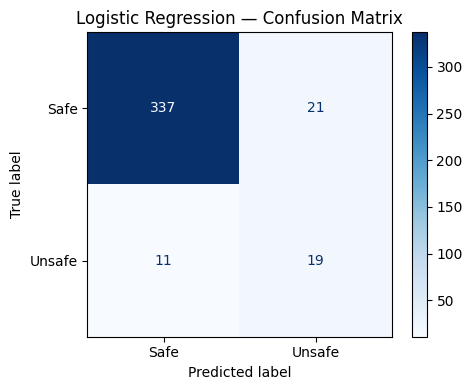

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=["Safe", "Unsafe"])
disp.plot(cmap="Blues", values_format="d", ax=ax)
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

## 7. MLP Neural Network — Default Parameters

We first train an MLP with **default sklearn parameters** (one hidden layer of 100 neurons, `relu`, `adam` solver). SMOTE is applied **only to the training set** inside the pipeline using `imblearn.pipeline` to prevent data leakage. The same preprocessor from Section 5 is reused.

In [ ]:
# MLP pipeline with SMOTE — default MLPClassifier parameters
mlp_default_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", MLPClassifier(random_state=42, max_iter=500))
])

mlp_default_pipeline.fit(X_train, y_train)

y_pred_mlp_def = mlp_default_pipeline.predict(X_test)
y_prob_mlp_def = mlp_default_pipeline.predict_proba(X_test)[:, 1]

mlp_def_acc  = accuracy_score(y_test, y_pred_mlp_def)
mlp_def_prec = precision_score(y_test, y_pred_mlp_def, zero_division=0)
mlp_def_rec  = recall_score(y_test, y_pred_mlp_def)
mlp_def_f1   = f1_score(y_test, y_pred_mlp_def)
mlp_def_auc  = roc_auc_score(y_test, y_prob_mlp_def)
mlp_def_cm   = confusion_matrix(y_test, y_pred_mlp_def)

print("MLP (Default Parameters) Performance")
print(f"Accuracy : {mlp_def_acc:.4f}")
print(f"Precision: {mlp_def_prec:.4f}")
print(f"Recall   : {mlp_def_rec:.4f}")
print(f"F1-score : {mlp_def_f1:.4f}")
print(f"ROC AUC  : {mlp_def_auc:.4f}")
print("\nConfusion Matrix:")
print(mlp_def_cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp_def, zero_division=0))

MLP (Default Parameters) Performance
Accuracy : 0.9098
Precision: 0.3684
Recall   : 0.2333
F1-score : 0.2857
ROC AUC  : 0.8547

Confusion Matrix:
[[346  12]
 [ 23   7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       358
           1       0.37      0.23      0.29        30

    accuracy                           0.91       388
   macro avg       0.65      0.60      0.62       388
weighted avg       0.89      0.91      0.90       388



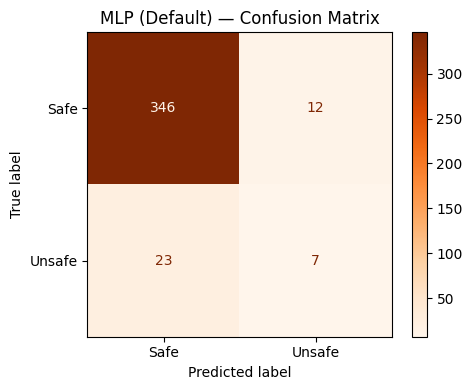

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=mlp_def_cm, display_labels=["Safe", "Unsafe"])
disp.plot(cmap="Oranges", values_format="d", ax=ax)
ax.set_title("MLP (Default) — Confusion Matrix")
plt.tight_layout()
plt.show()

## 8. Performance Comparison: Logistic Regression vs. MLP (Default)

We compare both models across five metrics. For this imbalanced problem, **Recall** (catching true unsafe wells) and **ROC AUC** are the most important metrics.

In [ ]:
comparison_df = pd.DataFrame({
    "Model":     ["Logistic Regression", "MLP (Default)"],
    "Accuracy":  [log_acc,       mlp_def_acc],
    "Precision": [log_prec,      mlp_def_prec],
    "Recall":    [log_rec,       mlp_def_rec],
    "F1":        [log_f1,        mlp_def_f1],
    "ROC_AUC":   [log_auc,       mlp_def_auc]
})

display(comparison_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.9175,0.4750,0.6333,0.5429,0.9035
1,MLP (Default),0.9098,0.3684,0.2333,0.2857,0.8547


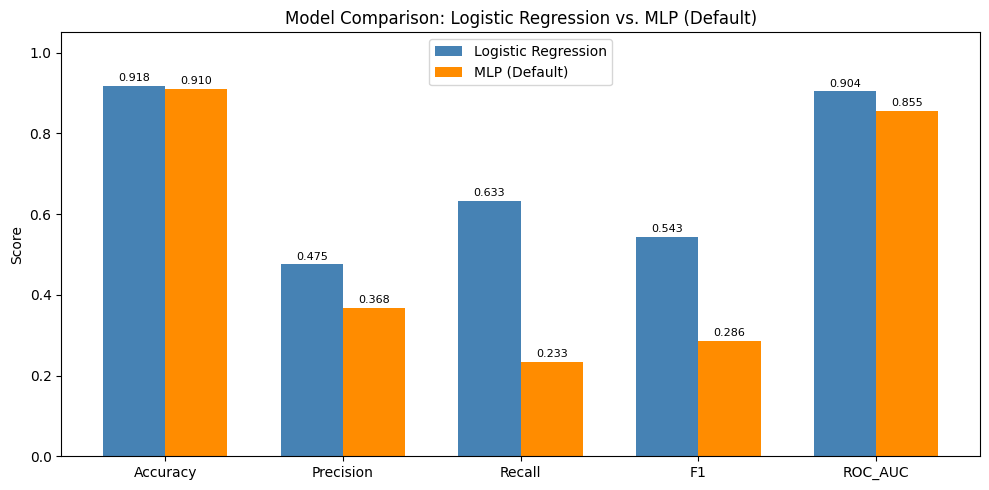

In [ ]:
# Bar chart comparison
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, comparison_df.loc[0, metrics], width, label="Logistic Regression", color="steelblue")
bars2 = ax.bar(x + width/2, comparison_df.loc[1, metrics], width, label="MLP (Default)",        color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Logistic Regression vs. MLP (Default)")
ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(bars2, fmt="%.3f", padding=2, fontsize=8)
plt.tight_layout()
plt.show()

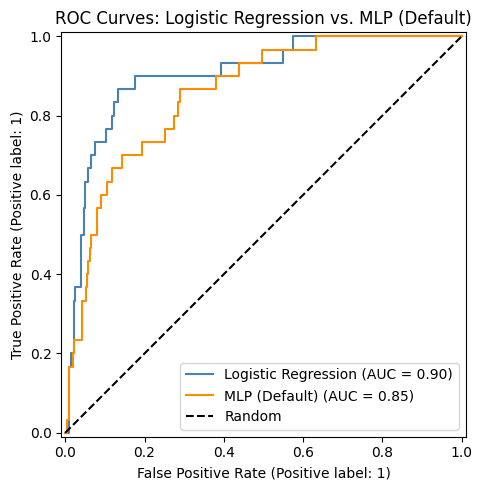

In [ ]:
# ROC curve comparison
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_log,     name="Logistic Regression", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test, y_prob_mlp_def, name="MLP (Default)",        ax=ax, color="darkorange")
ax.set_title("ROC Curves: Logistic Regression vs. MLP (Default)")
ax.plot([0, 1], [0, 1], 'k--', label="Random")
ax.legend()
plt.tight_layout()
plt.show()

## 9. MLP Hyperparameter Tuning

We use **GridSearchCV with 5-fold stratified cross-validation** to tune the MLP. The search covers:
- **Hidden layer sizes**: from compact `(32, 16)` to deeper architectures — smaller networks often generalize better on small datasets
- **Activation function**: `relu` vs `tanh`
- **Alpha** (L2 regularization): controls overfitting
- **Learning rate schedule**: `constant` vs `adaptive`

Scoring is optimized for **ROC AUC**, which is well-suited for imbalanced binary classification. Note: this step may take several minutes.

In [ ]:
# Base pipeline for tuning (preprocessor + SMOTE + MLP)
mlp_tune_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", MLPClassifier(random_state=42, max_iter=500, early_stopping=True,
                             validation_fraction=0.1, n_iter_no_change=15))
])

# Hyperparameter grid
param_grid = {
    "model__hidden_layer_sizes": [(32, 16), (64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    "model__activation":         ["relu", "tanh"],
    "model__alpha":               [0.0001, 0.001, 0.01],
    "model__learning_rate":       ["constant", "adaptive"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=mlp_tune_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)
print(f"\nBest CV ROC AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters:
{'model__activation': 'relu', 'model__alpha': 0.01, 'model__hidden_layer_sizes': (32, 16), 'model__learning_rate': 'constant'}

Best CV ROC AUC: 0.9073


### 9.1 Decision Threshold Tuning for the Tuned MLP

The default classification threshold of **0.5** is rarely optimal for imbalanced problems. The model's predicted probabilities for the minority (unsafe) class tend to cluster below 0.5, so even a well-trained model will predict few positives at this cutoff.

We sweep thresholds from 0.05 to 0.60 and report Precision, Recall, and F1 at each point. The goal is to find a threshold that **maximizes recall** (catching unsafe wells) while keeping F1 at a reasonable level. Note that **ROC AUC is threshold-independent** — it measures overall discrimination ability regardless of which cutoff is chosen.

In [ ]:
# Get probability outputs from the best tuned MLP
best_mlp = grid_search.best_estimator_
y_prob_mlp_tuned = best_mlp.predict_proba(X_test)[:, 1]
mlp_tuned_auc = roc_auc_score(y_test, y_prob_mlp_tuned)

# Threshold sweep
thresholds = np.arange(0.05, 0.65, 0.05)
thresh_rows = []
for t in thresholds:
    y_pred_t = (y_prob_mlp_tuned >= t).astype(int)
    thresh_rows.append({
        "Threshold": round(t, 2),
        "Precision": round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, y_pred_t), 4),
        "F1":        round(f1_score(y_test, y_pred_t, zero_division=0), 4)
    })

thresh_df = pd.DataFrame(thresh_rows)
styled = thresh_df.style\
    .highlight_max(subset=["Recall"], color="lightcoral", axis=0)\
    .highlight_max(subset=["F1"],     color="lightgreen", axis=0)
display(styled)

,Threshold,Precision,Recall,F1
0,0.050000,0.289500,0.733300,0.415100
1,0.100000,0.350900,0.666700,0.459800
2,0.150000,0.372100,0.533300,0.438400
3,0.200000,0.400000,0.533300,0.457100
4,0.250000,0.424200,0.466700,0.444400
5,0.300000,0.444400,0.400000,0.421100
6,0.350000,0.391300,0.300000,0.339600
7,0.400000,0.391300,0.300000,0.339600
8,0.450000,0.363600,0.266700,0.307700
9,0.500000,0.363600,0.266700,0.307700


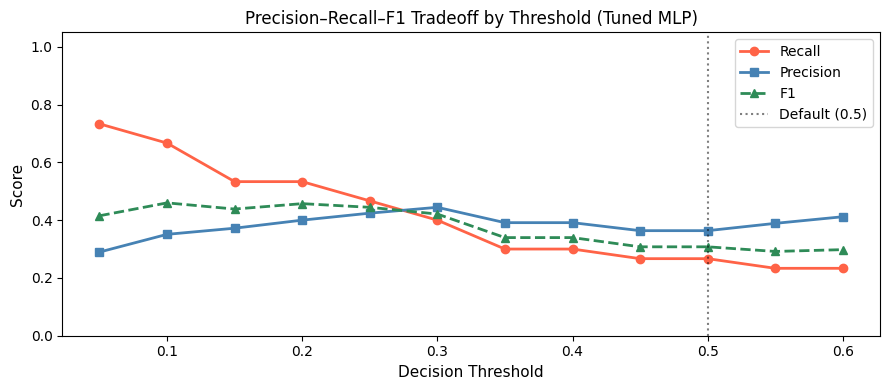

Threshold with best F1: 0.1
 Threshold  Precision  Recall     F1
       0.1     0.3509  0.6667 0.4598


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresh_df["Threshold"], thresh_df["Recall"],    marker="o", label="Recall",    color="tomato",    linewidth=2)
ax.plot(thresh_df["Threshold"], thresh_df["Precision"], marker="s", label="Precision", color="steelblue", linewidth=2)
ax.plot(thresh_df["Threshold"], thresh_df["F1"],        marker="^", label="F1",        color="seagreen",  linewidth=2, linestyle="--")
ax.axvline(x=0.5, color="black", linestyle=":", alpha=0.5, label="Default (0.5)")
ax.set_xlabel("Decision Threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Precision–Recall–F1 Tradeoff by Threshold (Tuned MLP)", fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

best_t = thresh_df.loc[thresh_df["F1"].idxmax(), "Threshold"]
print(f"Threshold with best F1: {best_t}")
print(thresh_df[thresh_df["Threshold"] == best_t].to_string(index=False))

### 9.2 Evaluate the Tuned MLP at Best Threshold

We apply the threshold that maximises F1 (identified above) and compute the final metrics. The ROC AUC reported here is threshold-independent and reflects the model's underlying discriminative ability.

In [ ]:
CHOSEN_THRESHOLD = best_t   # from sweep above; override manually if needed

y_pred_mlp_tuned = (y_prob_mlp_tuned >= CHOSEN_THRESHOLD).astype(int)

mlp_tuned_acc  = accuracy_score(y_test, y_pred_mlp_tuned)
mlp_tuned_prec = precision_score(y_test, y_pred_mlp_tuned, zero_division=0)
mlp_tuned_rec  = recall_score(y_test, y_pred_mlp_tuned)
mlp_tuned_f1   = f1_score(y_test, y_pred_mlp_tuned, zero_division=0)
mlp_tuned_cm   = confusion_matrix(y_test, y_pred_mlp_tuned)

print(f"MLP (Tuned, threshold={CHOSEN_THRESHOLD}) Performance")
print(f"Accuracy : {mlp_tuned_acc:.4f}")
print(f"Precision: {mlp_tuned_prec:.4f}")
print(f"Recall   : {mlp_tuned_rec:.4f}")
print(f"F1-score : {mlp_tuned_f1:.4f}")
print(f"ROC AUC  : {mlp_tuned_auc:.4f}  (threshold-independent)")
print("\nConfusion Matrix:")
print(mlp_tuned_cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp_tuned, target_names=["Safe", "Unsafe"], zero_division=0))

MLP (Tuned, threshold=0.1) Performance
Accuracy : 0.8789
Precision: 0.3509
Recall   : 0.6667
F1-score : 0.4598
ROC AUC  : 0.8638  (threshold-independent)

Confusion Matrix:
[[321  37]
 [ 10  20]]

Classification Report:
              precision    recall  f1-score   support

        Safe       0.97      0.90      0.93       358
      Unsafe       0.35      0.67      0.46        30

    accuracy                           0.88       388
   macro avg       0.66      0.78      0.70       388
weighted avg       0.92      0.88      0.90       388



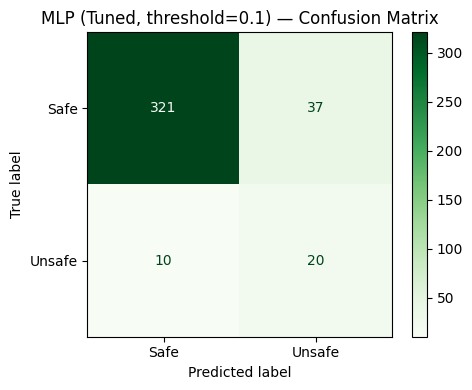

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=mlp_tuned_cm, display_labels=["Safe", "Unsafe"]).plot(
    cmap="Greens", values_format="d", ax=ax
)
ax.set_title(f"MLP (Tuned, threshold={CHOSEN_THRESHOLD}) — Confusion Matrix")
plt.tight_layout()
plt.show()

## 10. Final Comparison: All Three Models

We bring together all three models — Logistic Regression, MLP (Default), and MLP (Tuned with threshold) — for a comprehensive side-by-side comparison. The best value in each column is highlighted in green.

In [ ]:
final_comparison = pd.DataFrame({
    "Model":     [
        "Logistic Regression",
        "MLP (Default)",
        f"MLP (Tuned, threshold={CHOSEN_THRESHOLD})"
    ],
    "Accuracy":  [log_acc,      mlp_def_acc,   mlp_tuned_acc],
    "Precision": [log_prec,     mlp_def_prec,  mlp_tuned_prec],
    "Recall":    [log_rec,      mlp_def_rec,   mlp_tuned_rec],
    "F1":        [log_f1,       mlp_def_f1,    mlp_tuned_f1],
    "ROC_AUC":   [log_auc,      mlp_def_auc,   mlp_tuned_auc]
})

display(
    final_comparison.round(4).style.highlight_max(
        subset=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
        color="lightgreen", axis=0
    ).highlight_min(
        subset=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
        color="#ffe0e0", axis=0
    )
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.917500,0.475000,0.633300,0.542900,0.903500
1,MLP (Default),0.909800,0.368400,0.233300,0.285700,0.854700
2,"MLP (Tuned, threshold=0.1)",0.878900,0.350900,0.666700,0.459800,0.863800


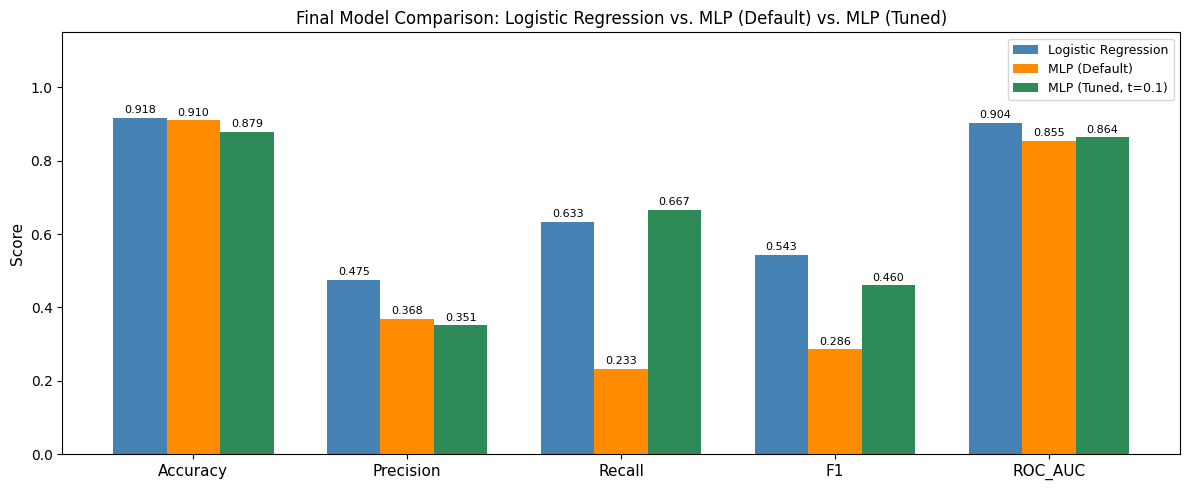

In [ ]:
# Bar chart — all three models
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
x      = np.arange(len(metrics))
width  = 0.25
colors = ["steelblue", "darkorange", "seagreen"]
labels = [
    "Logistic Regression",
    "MLP (Default)",
    f"MLP (Tuned, t={CHOSEN_THRESHOLD})"
]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (label, color) in enumerate(zip(labels, colors)):
    vals = final_comparison.loc[i, metrics].values.astype(float)
    bars = ax.bar(x + (i - 1) * width, vals, width, label=label, color=color)
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Final Model Comparison: Logistic Regression vs. MLP (Default) vs. MLP (Tuned)", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

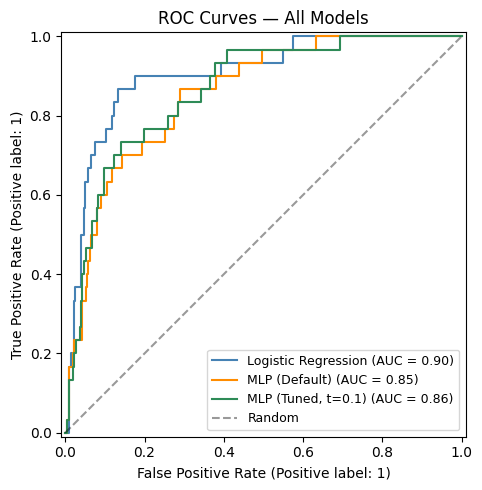

In [ ]:
# ROC curves — all three models
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_log,       name="Logistic Regression", ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test, y_prob_mlp_def,   name="MLP (Default)",        ax=ax, color="darkorange")
RocCurveDisplay.from_predictions(y_test, y_prob_mlp_tuned, name=f"MLP (Tuned, t={CHOSEN_THRESHOLD})", ax=ax, color="seagreen")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label="Random")
ax.set_title("ROC Curves — All Models", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 11. Summary

| Model | Accuracy | Precision | Recall | F1 | ROC_AUC |
|---|---|---|---|---|---|
| **Logistic Regression** | 0.9175 | 0.4750 | 0.6333 | 0.5429 | 0.9035 |
| **MLP (Default)** | 0.9098 | 0.3684 | 0.2333 | 0.2857 | 0.8547 |
| **MLP (Tuned, threshold=0.1)** | 0.8789 | 0.3509 | 0.6667 | 0.4598 | 0.8638 |

**Key findings:**

- **Logistic Regression** is the strongest overall model, achieving the highest Accuracy (0.9175), F1 (0.5429), and ROC AUC (0.9035). With `class_weight='balanced'`, it handles class imbalance well without additional techniques, making it a strong and interpretable baseline.

- **MLP (Default)** performs the weakest across all meaningful metrics, particularly Recall (0.2333) — it correctly identifies only about 1 in 4 unsafe wells. This confirms that the default threshold of 0.5 is poorly suited for imbalanced problems, as the model's predicted probabilities for the minority class cluster well below that cutoff.

- **MLP (Tuned, threshold=0.1)** recovers substantially on Recall (0.6667), matching Logistic Regression's ability to flag unsafe wells, at the cost of lower Accuracy (0.8789) and Precision (0.3509). The best architecture found by GridSearchCV was `(32, 16)` with `alpha=0.01` — a smaller, more regularized network that generalizes better given the limited dataset size (~1,550 samples).

- **ROC AUC is threshold-independent** and reflects the model's underlying discriminative ability. Logistic Regression leads on AUC (0.9035), while the tuned MLP (0.8638) outperforms the default MLP (0.8547), confirming that hyperparameter tuning improved the model even before threshold adjustment.

- **Threshold selection is critical for imbalanced classification.** Lowering the MLP threshold from 0.5 to 0.1 was necessary to make the tuned MLP competitive on Recall. This threshold should always be reported alongside metrics, as precision and recall are meaningless without knowing the operating point.

- Overall, **Logistic Regression remains the recommended model** for this problem — it achieves the best balance of recall, F1, and AUC with no threshold tuning required, and is more interpretable for a public health context.